# 02 — Data Collection

4 sumber data dikumpulkan terpisah (belum dibersihkan — itu tahap 03_data_processing):

1. **Venue wisata OSM** (`collect_osm.py`) — boundary DKI Jakarta admin_level=4, Overpass API
2. **Massive-STEPS-Jakarta** (`collect_steps.py`) — 412.100 check-in nyata Foursquare 2012-2018 (HuggingFace)
3. **Venue wisata Google Places** (`collect_venues_google.py`) — tambahan venue via Nearby Search, 12 kategori x 21 anchor
4. **Hotel Google Places** (`collect_hotels_google.py`) — 280 hotel, titik start/end itinerary

In [1]:
import sys
sys.path.insert(0, "../..")

import pandas as pd
import matplotlib.pyplot as plt
import config

## 1. Venue wisata OSM

In [2]:
print("Boundary area:", config.JAKARTA_AREA_NAME, "(admin_level", config.JAKARTA_AREA_ADMIN_LEVEL, ")")
print("Filter kategori wisata OSM:")
for k, v in config.TOURISM_FILTERS.items():
    print(f"  {k}: {v}")

Boundary area: Daerah Khusus Ibukota Jakarta (admin_level 4 )
Filter kategori wisata OSM:
  tourism: ['attraction', 'museum', 'viewpoint', 'zoo', 'theme_park', 'gallery', 'artwork', 'aquarium']
  leisure: ['park', 'garden']
  historic: None
  amenity: ['place_of_worship', 'marketplace']


Jalankan harvest (uncomment, butuh internet ~2-3 menit) atau skip ke hasil
run sebelumnya:

In [3]:
# import os
# sys.path.insert(0, "../../01_data_collection")
# import collect_osm
# collect_osm.main()

In [4]:
raw = pd.read_csv("../../data/raw/venues_osm_raw.csv")
print(f"Total venue OSM: {len(raw)}")
raw["venue_category"].value_counts().head(10)

Total venue OSM: 6166


venue_category
amenity:place_of_worship    5323
leisure:park                 392
amenity:marketplace          229
tourism:museum                39
tourism:attraction            37
tourism:artwork               24
historic:memorial             24
tourism:gallery               18
historic:monument             17
tourism:viewpoint             13
Name: count, dtype: int64

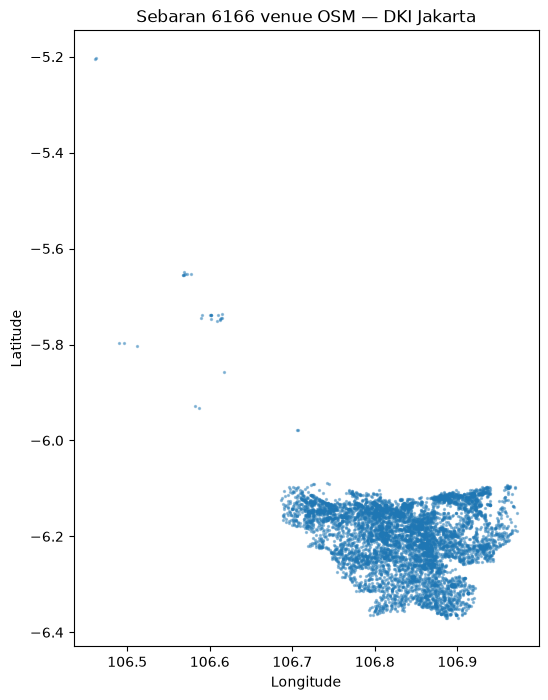

In [5]:
fig, ax = plt.subplots(figsize=(6, 8))
ax.scatter(raw["longitude"], raw["latitude"], s=2, alpha=0.4)
ax.set_title(f"Sebaran {len(raw)} venue OSM — DKI Jakarta")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

## 2. Hotel Google Places (titik berangkat/pulang itinerary)

Dipisah dari venue wisata — perannya beda (start/end point, bukan venue yang diskor/direkomendasikan).
Dikumpulkan via Google Places Nearby Search: 21 anchor point cover seluruh DKI + Kepulauan Seribu,
radius 5km per anchor, kategori `hotel/lodging/motel/guest_house/hostel`.

Keunggulan vs OSM hotel: rating nyata, price level, selalu update.

In [6]:
hotels = pd.read_csv("../../data/processed/hotels_google.csv")
print(f"Total hotel Google Places: {len(hotels)}")
print(f"Rating rata-rata: {hotels['google_rating'].mean():.2f}")
print(f"Hotel dengan rating: {hotels['google_rating'].notna().sum()}/{len(hotels)}")
print()
hotels[["name", "address", "google_rating", "google_rating_count", "price_level"]].head(10)

Total hotel Google Places: 280
Rating rata-rata: 4.41
Hotel dengan rating: 274/280



,name,address,google_rating,google_rating_count,price_level
0,Shangri-La Jakarta,"Shangri-La Jakarta, Kota BNI, Jl. Jenderal Sud...",4.7,26831.0,NaN
1,The St. Regis Jakarta,"Rajawali Place Jakarta, Jl. H. R. Rasuna Said ...",4.7,3161.0,NaN
2,Hotel Borobudur Jakarta,"Jl. Lap. Banteng Selatan No.1, Ps. Baru, Kecam...",4.6,22013.0,NaN
3,Pullman Jakarta Central Park,"Podomoro City Jl. Let. Jend S Parman Kav 28, J...",4.7,15510.0,NaN
4,AYANA Midplaza Jakarta,"Jl. Jenderal Sudirman No.Kav 10-11, RT.10/RW.1...",4.7,11419.0,NaN
5,Park Hyatt Jakarta,"Jl. Kebon Sirih No.17-19, RT.15/RW.7, Kb. Siri...",4.7,2811.0,NaN
6,Hotel Indonesia Kempinski Jakarta,"Jl. MH Thamrin No.1, RT.1/RW.5, Menteng, Kec. ...",4.7,22474.0,NaN
7,Pullman Jakarta Indonesia Thamrin CBD,"Jl. M.H. Thamrin No.59, RT.9/RW.5, Gondangdia,...",4.7,17186.0,NaN
8,Grand Mercure Jakarta Kemayoran,"Jl H Benyamin Sueb Kav B6, Superblok Mega Glod...",4.7,28297.0,NaN
9,Le Meridien Jakarta,"Jl. Jenderal Sudirman No.Kav 18 - 20, RT.10/RW...",4.6,13275.0,NaN


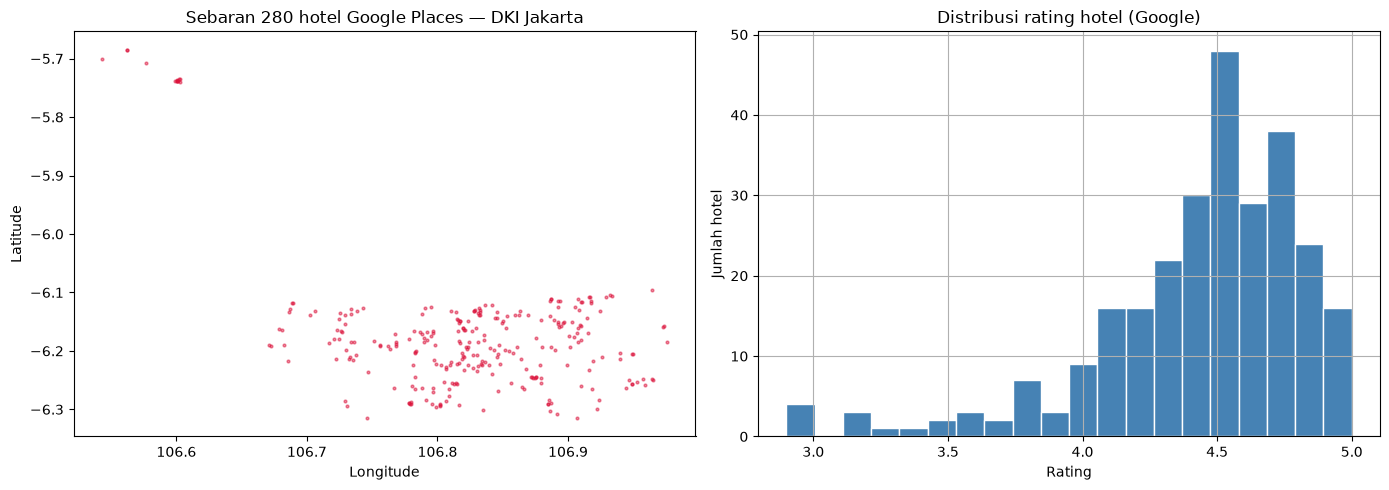

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(hotels["longitude"], hotels["latitude"], s=4, alpha=0.5, color="crimson")
axes[0].set_title(f"Sebaran {len(hotels)} hotel Google Places — DKI Jakarta")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

hotels["google_rating"].dropna().hist(bins=20, ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title("Distribusi rating hotel (Google)")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Jumlah hotel")

plt.tight_layout()
plt.show()

## 3. Massive-STEPS-Jakarta (check-in nyata)

Dataset penelitian publik (HuggingFace), berisi check-in nyata pengguna
Foursquare-style historis (2012-2018) -- bukan OSM, bukan simulasi.
`checkin_count` per venue jadi proxy popularitas **nyata**, pengganti
`unique_visitors` sintetis pada venue yang berhasil di-merge.

In [8]:
print(f"Repo: {config.STEPS_REPO_ID}")

Repo: CRUISEResearchGroup/Massive-STEPS-Jakarta


Jalankan download (uncomment, butuh internet) atau skip ke hasil run
sebelumnya:

In [9]:
# sys.path.insert(0, "../../01_data_collection")
# import collect_steps
# collect_steps.main()

In [10]:
checkins = pd.read_csv("../../data/raw/jakarta_checkins_raw.csv")
venues_steps = pd.read_csv("../../data/processed/steps_venues_raw.csv")
print(f"Total check-in (mentah): 412.100")
print(f"Setelah drop null lat/lon/name: {len(checkins)}")
print(f"Venue unik (agregasi per venue_id): {len(venues_steps)}")

Total check-in (mentah): 412.100
Setelah drop null lat/lon/name: 333191
Venue unik (agregasi per venue_id): 49291


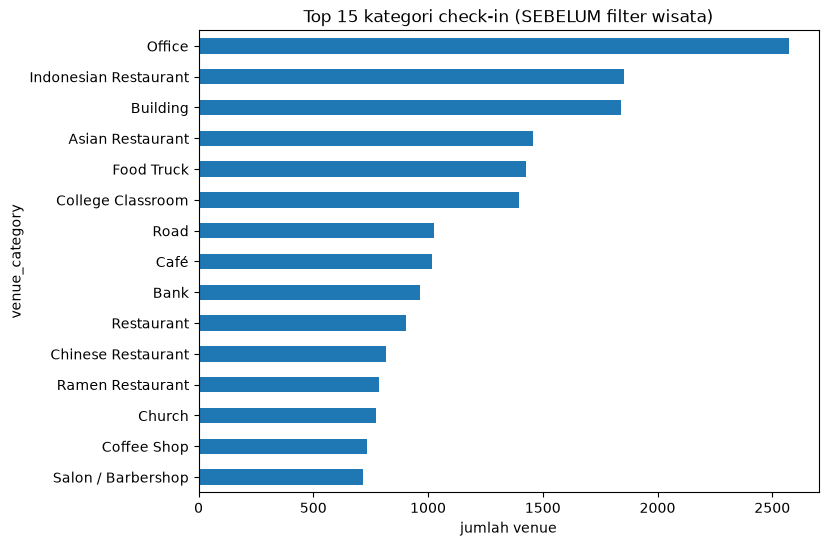

In [11]:
venues_steps["venue_category"].value_counts().head(15).plot(
    kind="barh", figsize=(8, 6), title="Top 15 kategori check-in (SEBELUM filter wisata)")
plt.xlabel("jumlah venue")
plt.gca().invert_yaxis()
plt.show()

Catatan: kategori didominasi Office/Home/Building/Restaurant -- check-in
Foursquare-style umum, bukan khusus wisata. Filter ke kategori wisata
dilakukan di tahap berikutnya (`03_data_processing.ipynb`).

## 3. Venue wisata Google Places (tambahan)

Massive-STEPS cakupan tidak merata — venue terkenal yang tidak populer di Foursquare 2012-2018
(Kebun Binatang Ragunan, venue baru post-2018) tidak tercatat.

Solusi: `collect_venues_google.py` — Nearby Search Google Places API per kategori x 21 anchor point
cover seluruh DKI Jakarta + Kepulauan Seribu. Output: `data/raw/venues_google_raw.csv` (980 venue mentah,
sebelum filter noise di tahap preprocessing).

In [12]:
gvenues = pd.read_csv("../../data/raw/venues_google_raw.csv")
print(f"Total venue Google raw: {len(gvenues)} (sebelum filter)")
print(f"Rating rata-rata: {gvenues['google_rating'].mean():.2f}")
print()
print("Distribusi kategori (raw):")
print(gvenues["venue_category"].value_counts().to_string())
print()
print("Catatan: 980 → 155 venue baru setelah filter di tahap preprocessing")

Total venue Google raw: 980 (sebelum filter)
Rating rata-rata: 4.61

Distribusi kategori (raw):
venue_category
Historic Site          230
Art Museum             221
Museum                 216
Aquarium               154
Theme Park             110
Zoo                     34
Monument / Landmark      6
Beach                    5
History Museum           4

Catatan: 980 → 155 venue baru setelah filter di tahap preprocessing


## 4. Ringkasan semua sumber data

| Sumber | File | Jumlah | Keterangan |
|--------|------|--------|-----------|
| OSM Overpass | `venues_osm_raw.csv` | ~6.166 | Venue wisata Jakarta, mayoritas tempat ibadah |
| Massive-STEPS | `jakarta_checkins_raw.csv` | 333.191 check-in | 49.291 venue unik, data behavior nyata |
| Google Places venue | `venues_google_raw.csv` | 980 | Tambahan venue, difilter di preprocessing → 155 baru |
| Google Places hotel | `hotels_google.csv` | 280 | Titik start/end itinerary, rating nyata |

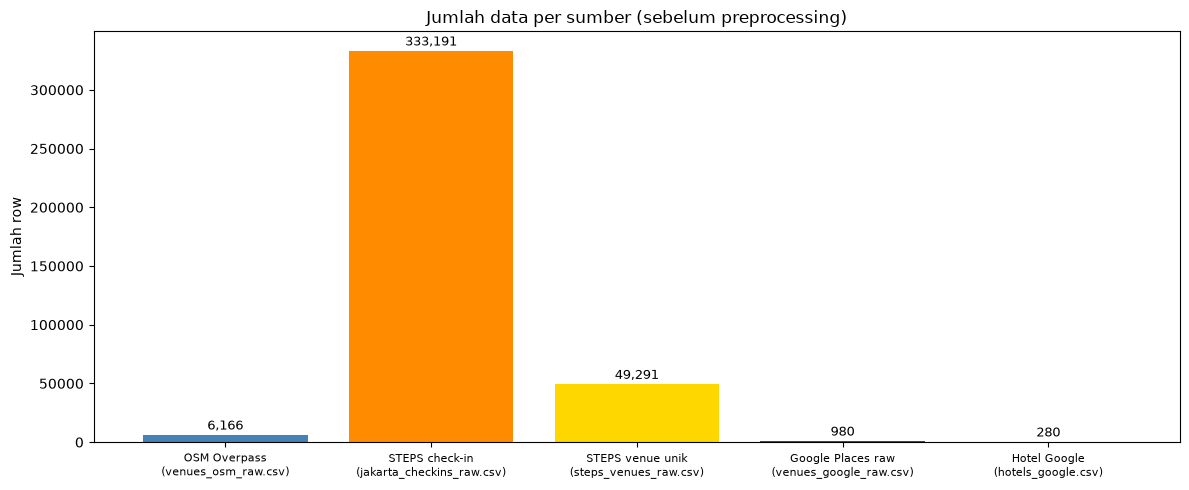

In [13]:
import os

sumber = {
    "OSM Overpass\n(venues_osm_raw.csv)": len(pd.read_csv("../../data/raw/venues_osm_raw.csv")),
    "STEPS check-in\n(jakarta_checkins_raw.csv)": len(checkins),
    "STEPS venue unik\n(steps_venues_raw.csv)": len(venues_steps),
    "Google Places raw\n(venues_google_raw.csv)": len(gvenues),
    "Hotel Google\n(hotels_google.csv)": len(hotels),
}

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(sumber.keys(), sumber.values(), color=["steelblue","darkorange","gold","green","crimson"])
ax.set_title("Jumlah data per sumber (sebelum preprocessing)")
ax.set_ylabel("Jumlah row")
for bar, val in zip(bars, sumber.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f"{val:,}", ha="center", va="bottom", fontsize=9)
plt.xticks(fontsize=8)
plt.tight_layout()
plt.show()